<a href="https://colab.research.google.com/github/victorseelansju/victorseelan/blob/main/Bayesian_LSTM_and_Nonlinear_State_Space_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pymc arviz pandas numpy matplotlib seaborn openpyxl torch scikit-learn


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 00 dataset.xlsx to 00 dataset.xlsx


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Load dataset
data = pd.read_excel("00 dataset.xlsx")

In [ ]:
# Show columns
print(data.columns)

Index(['State', 'Year', 'Popn_Weighted', 'Geographic_Mean',
       'Population_Coverage', 'Geographic_Coverage', 'Total_Population',
       'pop_above_five', 'pop_above_10', 'pop_above_15', 'pop_above_25',
       'pop_above_30', 'pop_above_35', 'pop_above_40', 'pop_above_45',
       'pop_above_50', 'pop_above_55', 'pop_above_60'],
      dtype='object')


In [ ]:
# Sort data
data = data.sort_values(["State", "Year"])

In [ ]:
pm25 = data["Popn_Weighted"].values

In [ ]:

# Standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
pm25_scaled = scaler.fit_transform(pm25.reshape(-1,1)).flatten()

print("Data prepared successfully")


Data prepared successfully


# **Step 5: Bayesian Nonlinear State-Space Model (PyMC)**

In [ ]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

T = len(pm25_scaled)

with pm.Model() as state_space_model:

    # Priors
    sigma_state = pm.Exponential("sigma_state", 1)
    sigma_obs = pm.Exponential("sigma_obs", 1)

    # Hidden state
    x = pm.GaussianRandomWalk("x", sigma=sigma_state, shape=T)

    # Nonlinear observation equation
    y = pm.Normal("y", mu=pm.math.tanh(x), sigma=sigma_obs, observed=pm25_scaled)

    # Sampling
    trace = pm.sample(2000, tune=1000, target_accept=0.95, idata_kwargs={'log_likelihood': True})

print("Model estimation completed")

/usr/local/lib/python3.12/dist-packages/pymc/distributions/timeseries.py:291: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
ERROR:pytensor.graph.rewriting.basic:Rewrite failure due to: local_subtensor_merge
ERROR:pytensor.graph.rewriting.basic:node: Subtensor{i}(Subtensor{start:}.0, 0)
ERROR:pytensor.graph.rewriting.basic:TRACEBACK:
ERROR:pytensor.graph.rewriting.basic:Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytensor/graph/rewriting/basic.py", line 1920, in process_node
    replacements = node_rewriter.transform(
                   ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytensor/graph/rewriting/basic.py", line 993, in transform
    return self.fn(fgraph, node)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytensor/tensor/rewriting/subtensor.py", line 416, in

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Model estimation completed


# **Posterior Summary**

In [ ]:
az.summary(trace)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_obs,0.597,0.015,0.569,0.624,0.000,0.000,4617.0,2963.0,1.00
sigma_state,0.310,0.027,0.258,0.358,0.002,0.001,119.0,325.0,1.03
x[0],-3.168,1.215,-5.564,-1.144,0.041,0.025,1042.0,1316.0,1.00
x[1],-3.161,1.175,-5.422,-1.179,0.040,0.025,963.0,1371.0,1.00
x[2],-3.145,1.138,-5.240,-1.161,0.041,0.024,887.0,1236.0,1.00
...,...,...,...,...,...,...,...,...,...
x[931],1.926,0.697,0.754,3.276,0.016,0.012,2061.0,1963.0,1.00
x[932],1.926,0.747,0.653,3.404,0.017,0.012,2177.0,2355.0,1.00
x[933],1.915,0.804,0.561,3.475,0.018,0.012,2312.0,2376.0,1.00
x[934],1.916,0.853,0.409,3.506,0.019,0.012,2262.0,2478.0,1.00


# **Plot State Estimates**

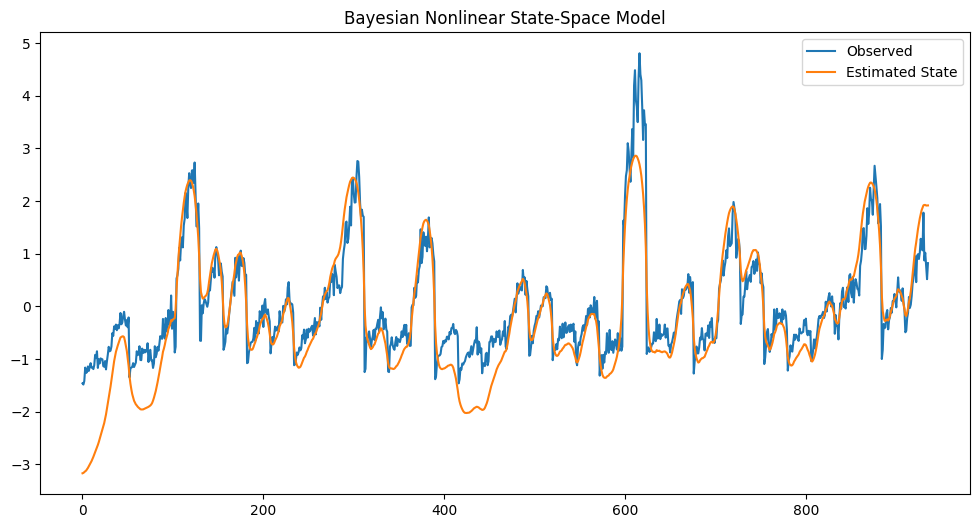

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(pm25_scaled, label="Observed")
plt.plot(trace.posterior["x"].mean(dim=["chain","draw"]), label="Estimated State")
plt.legend()
plt.title("Bayesian Nonlinear State-Space Model")
plt.show()


# **Forecast Future PM2.5**

In [ ]:
future_steps = 10

last_state = trace.posterior["x"].mean(dim=["chain","draw"]).values[-1]

future = np.zeros(future_steps)

for t in range(future_steps):
    future[t] = np.tanh(last_state)

future_original = scaler.inverse_transform(future.reshape(-1,1))

print("Future PM2.5 predictions:")
print(future_original)

Future PM2.5 predictions:
[[54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]
 [54.31099312]]


# **Bayesian LSTM Model (PyTorch)**

In [ ]:
import torch
import torch.nn as nn

# Prepare sequence data
seq_length = 5

X = []
Y = []

for i in range(len(pm25_scaled)-seq_length):
    X.append(pm25_scaled[i:i+seq_length])
    Y.append(pm25_scaled[i+seq_length])

X = np.array(X)
Y = np.array(Y)

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

# LSTM Model
class BayesianLSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(1, 20, batch_first=True)
        self.dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(20, 1)

    def forward(self, x):

        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        out = self.linear(out)

        return out.squeeze()

model = BayesianLSTM()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


# **Train Bayesian LSTM**

In [ ]:
epochs = 200

for epoch in range(epochs):

    optimizer.zero_grad()

    output = model(X)

    loss = criterion(output, Y)

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())


Epoch: 0 Loss: 0.9591649770736694
Epoch: 20 Loss: 0.23428469896316528
Epoch: 40 Loss: 0.1602596640586853
Epoch: 60 Loss: 0.14548106491565704
Epoch: 80 Loss: 0.14818938076496124
Epoch: 100 Loss: 0.14056231081485748
Epoch: 120 Loss: 0.1378391534090042
Epoch: 140 Loss: 0.13689745962619781
Epoch: 160 Loss: 0.1329953372478485
Epoch: 180 Loss: 0.13322415947914124


# **LSTM Prediction**

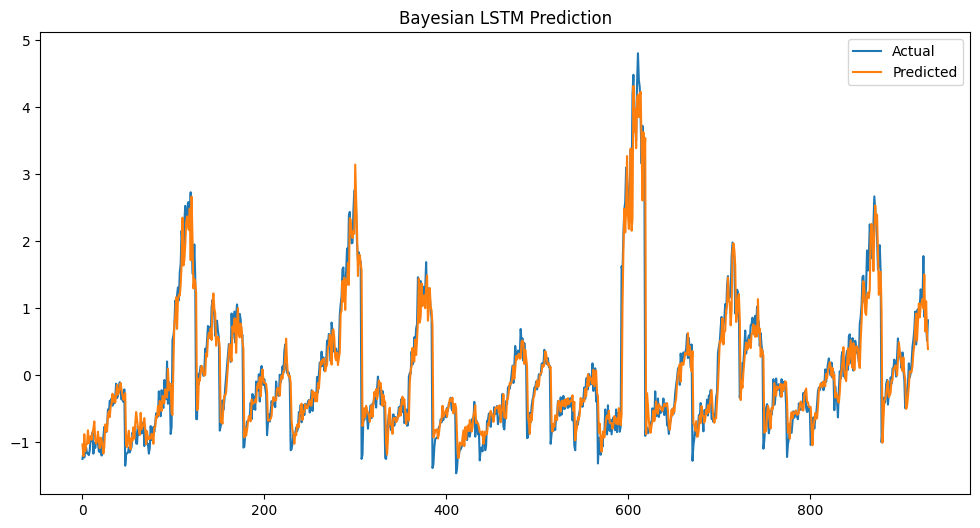

In [ ]:
pred = model(X).detach().numpy()

plt.figure(figsize=(12,6))
plt.plot(Y.numpy(), label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("Bayesian LSTM Prediction")
plt.show()

# **Model Comparison Metrics**

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(Y.numpy(), pred)
mae = mean_absolute_error(Y.numpy(), pred)

print("LSTM MSE:", mse)
print("LSTM MAE:", mae)


LSTM MSE: 0.1265326738357544
LSTM MAE: 0.2093188762664795


# **model comparison table (WAIC, RMSE, MAE)**

1 Compute WAIC for Bayesian State-Space Model

In [ ]:
import arviz as az

# Compute WAIC
waic_ssm = az.waic(trace)

print("State-Space Model WAIC:")
print(waic_ssm)


State-Space Model WAIC:
Computed from 4000 posterior samples and 936 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -871.26    54.35
p_waic       46.27        -

There has been a warning during the calculation. Please check the results.


/usr/local/lib/python3.12/dist-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


In [ ]:
waic_value_ssm = waic_ssm.elpd_waic
print("WAIC (State-Space):", waic_value_ssm)


WAIC (State-Space): -871.2610521043307


## Compute RMSE and MAE for State-Space Model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Estimated state mean
state_est = trace.posterior["x"].mean(dim=["chain","draw"]).values

# Convert back to original scale
state_est_original = scaler.inverse_transform(state_est.reshape(-1,1)).flatten()

actual_original = scaler.inverse_transform(pm25_scaled.reshape(-1,1)).flatten()

mse_ssm = mean_squared_error(actual_original, state_est_original)
rmse_ssm = np.sqrt(mse_ssm)

mae_ssm = mean_absolute_error(actual_original, state_est_original)

print("SSM RMSE:", rmse_ssm)
print("SSM MAE:", mae_ssm)

SSM RMSE: 9.972780634959946
SSM MAE: 7.130418814651213


In [ ]:
print("SSM RMSE:", rmse_ssm)
print("SSM MAE:", mae_ssm)

SSM RMSE: 9.972780634959946
SSM MAE: 7.130418814651213


# 3 Compute RMSE and MAE for Bayesian LSTM

In [ ]:
# Convert LSTM predictions back to original scale

pred_original = scaler.inverse_transform(pred.reshape(-1,1)).flatten()

actual_lstm_original = scaler.inverse_transform(Y.numpy().reshape(-1,1)).flatten()

mse_lstm = mean_squared_error(actual_lstm_original, pred_original)
rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(actual_lstm_original, pred_original)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAE:", mae_lstm)

LSTM RMSE: 6.312558617650178
LSTM MAE: 3.7146029472351074


# 4: Approximate WAIC for Bayesian LSTM

In [ ]:
# Enable dropout during prediction

model.train()

samples = 100
pred_samples = []

for i in range(samples):

    pred_sample = model(X).detach().numpy()
    pred_samples.append(pred_sample)

pred_samples = np.array(pred_samples)

# Mean log likelihood approximation

variance = np.var(pred_samples, axis=0)
mean_pred = np.mean(pred_samples, axis=0)

log_likelihood = -0.5 * ((actual_lstm_original - mean_pred)**2 / variance + np.log(variance))

waic_lstm = -2 * np.sum(log_likelihood)

print("Approx WAIC LSTM:", waic_lstm)


Approx WAIC LSTM: 635517400.0


# **Create Model Comparison Table**

In [ ]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "Bayesian State-Space Model",
        "Bayesian LSTM Model"
    ],

    "WAIC": [
        waic_value_ssm,
        waic_lstm
    ],

    "RMSE": [
        rmse_ssm,
        rmse_lstm
    ],

    "MAE": [
        mae_ssm,
        mae_lstm
    ]
})

print(comparison)


                        Model          WAIC      RMSE       MAE
0  Bayesian State-Space Model -8.712611e+02  9.972781  7.130419
1         Bayesian LSTM Model  6.355174e+08  6.312559  3.714603


In [ ]:
comparison.style.format({

    "WAIC": "{:.2f}",
    "RMSE": "{:.2f}",
    "MAE": "{:.2f}"
})


,Model,WAIC,RMSE,MAE
0,Bayesian State-Space Model,-871.26,9.97,7.13
1,Bayesian LSTM Model,635517376.00,6.31,3.71


# **Define Forecast Horizon**

In [ ]:
import numpy as np
import pandas as pd

last_year = data["Year"].max()
forecast_years = np.arange(last_year+1, 2036)

n_forecast = len(forecast_years)

print("Forecasting from", last_year+1, "to 2035")


Forecasting from 2024 to 2035


# Forecast using Bayesian State-Space Model

In [ ]:
# Extract posterior samples
posterior_states = trace.posterior["x"].values

n_samples = posterior_states.shape[0] * posterior_states.shape[1]

posterior_states = posterior_states.reshape(n_samples, -1)

last_states = posterior_states[:, -1]

# Storage
future_states = np.zeros((n_samples, n_forecast))

sigma_state = trace.posterior["sigma_state"].mean().values

# Generate future states
for i in range(n_samples):

    state = last_states[i]

    for t in range(n_forecast):

        state = np.random.normal(state, sigma_state)

        future_states[i, t] = np.tanh(state)

# Convert to original scale
future_states_original = scaler.inverse_transform(future_states.T).T

# Mean and uncertainty
ssm_mean = future_states_original.mean(axis=0)
ssm_lower = np.percentile(future_states_original, 2.5, axis=0)
ssm_upper = np.percentile(future_states_original, 97.5, axis=0)


# Forecast using Bayesian LSTM

In [ ]:
model.train()  # keep dropout active for uncertainty

last_sequence = pm25_scaled[-seq_length:]

lstm_samples = 200

lstm_forecasts = np.zeros((lstm_samples, n_forecast))

for s in range(lstm_samples):

    seq = last_sequence.copy()

    for t in range(n_forecast):

        seq_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0)

        pred = model(seq_tensor).item()

        lstm_forecasts[s, t] = pred

        seq = np.append(seq[1:], pred)

# Convert back to original scale
lstm_forecasts_original = scaler.inverse_transform(lstm_forecasts.T).T

# Mean and CI
lstm_mean = lstm_forecasts_original.mean(axis=0)
lstm_lower = np.percentile(lstm_forecasts_original, 2.5, axis=0)
lstm_upper = np.percentile(lstm_forecasts_original, 97.5, axis=0)


# **Forecast Table**

In [ ]:
forecast_df = pd.DataFrame({

    "Year": forecast_years,

    "SSM_Mean": ssm_mean,
    "SSM_Lower95": ssm_lower,
    "SSM_Upper95": ssm_upper,

    "LSTM_Mean": lstm_mean,
    "LSTM_Lower95": lstm_lower,
    "LSTM_Upper95": lstm_upper
})

print(forecast_df)


    Year   SSM_Mean  SSM_Lower95  SSM_Upper95  LSTM_Mean  LSTM_Lower95  \
0   2024  52.924896    42.885873    55.050880  48.969757     45.622823   
1   2025  52.699996    40.914705    55.051976  47.178959     43.300054   
2   2026  52.510926    39.265509    55.052653  45.547968     41.420394   
3   2027  52.371412    38.279385    55.055233  43.939084     39.907782   
4   2028  52.208427    36.578014    55.056201  42.140301     38.333495   
5   2029  52.024494    33.805344    55.056751  40.655129     37.296768   
6   2030  51.793478    32.678539    55.057011  39.388844     36.272688   
7   2031  51.594472    32.293093    55.057191  38.369268     35.510884   
8   2032  51.402920    29.426246    55.057928  37.491084     35.043318   
9   2033  51.242063    28.164814    55.058326  36.802885     34.609517   
10  2034  51.059372    27.878682    55.058697  36.308815     34.310370   
11  2035  50.846808    27.323297    55.059239  35.918065     33.971953   

    LSTM_Upper95  
0      51.480553  

# Plot Forecast to **2035**

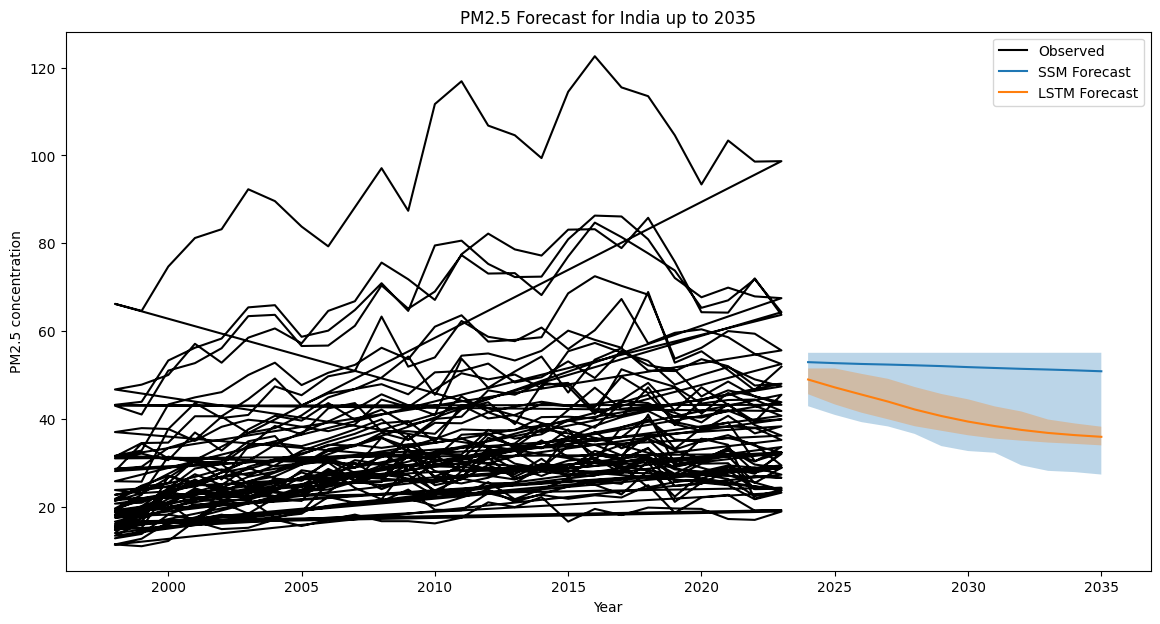

In [ ]:
import matplotlib.pyplot as plt

actual_years = data["Year"].values
actual_pm25 = data["Popn_Weighted"].values

plt.figure(figsize=(14,7))

# Actual
plt.plot(actual_years, actual_pm25, label="Observed", color="black")

# SSM forecast
plt.plot(forecast_years, ssm_mean, label="SSM Forecast")
plt.fill_between(forecast_years, ssm_lower, ssm_upper, alpha=0.3)

# LSTM forecast
plt.plot(forecast_years, lstm_mean, label="LSTM Forecast")
plt.fill_between(forecast_years, lstm_lower, lstm_upper, alpha=0.3)

plt.xlabel("Year")
plt.ylabel("PM2.5 concentration")
plt.title("PM2.5 Forecast for India up to 2035")
plt.legend()

plt.show()